# Installation

In [1]:
# ✅ Toujours utiliser %pip dans Colab
%pip uninstall -y mmpose mmcv mmcv-lite mmdet >/dev/null 2>&1

# mmcv-lite en premier, PAS de C++ ops
%pip install -q mmcv-lite==2.0.1

# mmdet sans deps pour ne PAS tirer "mmcv" full
%pip install -q --no-deps mmdet==3.3.0

# Récupère le code MMPose v1.3.2 et PATCH pour éviter l'import des têtes "transformer"
import os, shutil, subprocess, textwrap, sys
repo = "/content/mmpose_cpu_patch"
shutil.rmtree(repo, ignore_errors=True)
subprocess.check_call(["git","clone","--depth","1","--branch","v1.3.2",
                       "https://github.com/open-mmlab/mmpose.git", repo])

# 1) Retirer 'chumpy' (inutile en 2D et problématique en Py3.12)
for meta in ("setup.cfg","pyproject.toml"):
    p = os.path.join(repo, meta)
    if os.path.exists(p):
        s = open(p,"r",encoding="utf-8").read().replace("chumpy","")
        open(p,"w",encoding="utf-8").write(s)

# 2) Désactiver totalement les "transformer_heads" (EDPose)
heads_init = os.path.join(repo, "mmpose/models/heads/__init__.py")
if os.path.exists(heads_init):
    s = open(heads_init,"r",encoding="utf-8").read()
    # supprime toute ligne qui importe transformer_heads
    s = "\n".join([ln for ln in s.splitlines() if "transformer_heads" not in ln])
    open(heads_init,"w",encoding="utf-8").write(s)

# 3) Supprime le dossier des transformer_heads pour être 100% safe
tf_dir = os.path.join(repo, "mmpose/models/heads/transformer_heads")
shutil.rmtree(tf_dir, ignore_errors=True)

# Installe le paquet patché (non-editable pour éviter les soucis de chemins)
%pip install -q /content/mmpose_cpu_patch

# Sanity checks
import importlib.util, pkgutil, mmcv, mmpose
print("mmcv version:", getattr(mmcv, "__version__", "N/A"))
print("mmcv._ext chargeable ?",
      end=" ")
try:
    import mmcv._ext as _ext
    print("Oui (peu probable en CPU).")
except Exception as e:
    print("Non (c'est attendu en CPU).")
print("mmpose file:", getattr(mmpose, "__file__", None))
print("mmpose.apis visible ?",
      importlib.util.find_spec("mmpose.apis") is not None)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 715.0/715.0 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
mmcv version: 2.0.1
mmcv._ext chargeable ? Non (c'est attendu en CPU).
mmpose file: /usr/local/lib/python3.12/dist-packages/mmpose/__init__.py
mmpose.apis visible ? True


# Nettoyage

In [2]:
from pathlib import Path

# 1) Supprime les imports/mentions d'EDPoseHead & transformer_heads dans heads/__init__.py
p_heads = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py')
txt = p_heads.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_heads.write_text(txt2, encoding='utf-8')

# 2) Supprime les mentions d'EDPoseHead & transformer_heads dans models/__init__.py
p_models = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py')
txt = p_models.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_models.write_text(txt2, encoding='utf-8')

print("Patched:", p_heads, "and", p_models)

# 3) Purge le cache d'import mmpose pour recharger les fichiers patchés
for k in list(sys.modules):
    if k.startswith('mmpose'):
        del sys.modules[k]
print("Import cache purged for mmpose.*")


Patched: /usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py and /usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py
Import cache purged for mmpose.*


# Téléchargement des poids du modèle (HRNetv2 avec dataset coco wholebody-hand)

In [3]:
import urllib.request

os.makedirs("/content/checkpoints", exist_ok=True)

# Checkpoint HRNetv2 (heatmap, compatible CPU)
ckpt = "/content/checkpoints/hrnetv2_w18_coco_256x256.pth"
if not os.path.exists(ckpt):
    urllib.request.urlretrieve(
        "https://download.openmmlab.com/mmpose/hand/hrnetv2/hrnetv2_w18_coco_wholebody_hand_256x256-1c028db7_20210908.pth",
        ckpt
    )

# Config (on prend celle de MMPose 1.3.2)
CFG = "/content/mmpose_cpu_patch/configs/hand_2d_keypoint/topdown_heatmap/coco_wholebody_hand/td-hm_hrnetv2-w18_8xb32-210e_coco-wholebody-hand-256x256.py"

print("Config et checkpoint prêts.")


Config et checkpoint prêts.


In [4]:
# Imports
%pip install mediapipe

# charger le modèle en CPU
from mmpose.apis import init_model

from PIL import Image as PILImage
import matplotlib.pyplot as plt
import numpy as np
from mmpose.apis import inference_topdown
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe import Image
import cv2

import glob
import pandas as pd

# Détection de la main sur l'image
%pip install mediapipe opencv-python matplotlib
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:33: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv`` rather than ``mmcv-lite`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '


# Chargement du modèle

In [5]:
model = init_model(CFG, ckpt, device="cpu")
print("Modèle chargé avec CFG =", CFG)

Loads checkpoint by local backend from path: /content/checkpoints/hrnetv2_w18_coco_256x256.pth
Modèle chargé avec CFG = /content/mmpose_cpu_patch/configs/hand_2d_keypoint/topdown_heatmap/coco_wholebody_hand/td-hm_hrnetv2-w18_8xb32-210e_coco-wholebody-hand-256x256.py


/usr/local/lib/python3.12/dist-packages/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/coco_wholebody_hand.py" does not exist. A matched config file "/usr/local/lib/python3.12/dist-packages/mmpose/.mim/configs/_base_/datasets/coco_wholebody_hand.py" will be used instead.
  warnings.warn(


# Création des dossiers des données à traiter (Importer manuellement les images/vidéos)

* dossier images : images pour tester le modèle
* dossier video : video à étudier
* dossier full_frames : frames extraites de la vidéo
* dossier hand_frames : frames découpées centrées sur les mains pour faciliter la détection

In [6]:
os.makedirs('/content/images', exist_ok=True)
os.makedirs("/content/video", exist_ok=True)
os.makedirs("/content/full_frames", exist_ok=True)
os.makedirs("/content/hand_frames", exist_ok=True)

In [ ]:
# Réinitialisation des dossiers
!rm -rf /content/images/*
!rm -rf /content/video/*
!rm -rf /content/full_frames/*
!rm -rf /content/hand_frames/*

# I. Main droite seule sur fond neutre

On s'intéresse pour l'instant à des images de mains vue de haut (dos de la main vers la caméra, doigts vers le haut de l'image, posture neutre au piano)

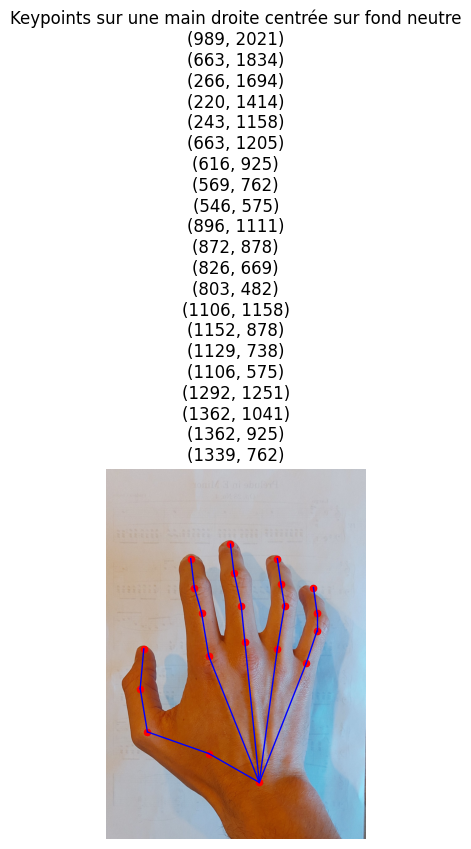

In [7]:
# Définition du squelette de la main
HAND_SKELETON = [ # Pour le tracé du squelette reliant les keypoints
    (0, 1), (1, 2), (2, 3), (3, 4),       # pouce
    (0, 5), (5, 6), (6, 7), (7, 8),       # index
    (0, 9), (9,10), (10,11), (11,12),     # majeur
    (0,13), (13,14), (14,15), (15,16),    # annulaire
    (0,17), (17,18), (18,19), (19,20)     # auriculaire
]

def draw_hand_skeleton(hand_keypoints): # Fournir les coordonnées des keypoints associés à UNE main
    # Tracé des keypoints
    for (x, y) in hand_keypoints:
        plt.scatter(x, y, c='red', s=20)

    # Tracé du squelette
    for i, j in HAND_SKELETON:
        x_vals = [hand_keypoints[i, 0], hand_keypoints[j, 0]]
        y_vals = [hand_keypoints[i, 1], hand_keypoints[j, 1]]
        plt.plot(x_vals, y_vals, c='blue', linewidth=1)

img_path = '/content/images/main_fond_neutre.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path, bboxes=[[0, 0, W, H]], bbox_format='xyxy')

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite centrée sur fond neutre\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

# II. Main droite seule sur piano

Le modèle n'a pas de difficulté particulière pour placer les keypoints sur une main dans des conditions idéales (la main est l'unique objet dans le cadre, fond neutre, luminosité acceptable...). Avant de passer à la vidéo, il convient de vérifier que notre modèle est capable de détecter correctement une main lorsque celle-ci est posée sur un piano.

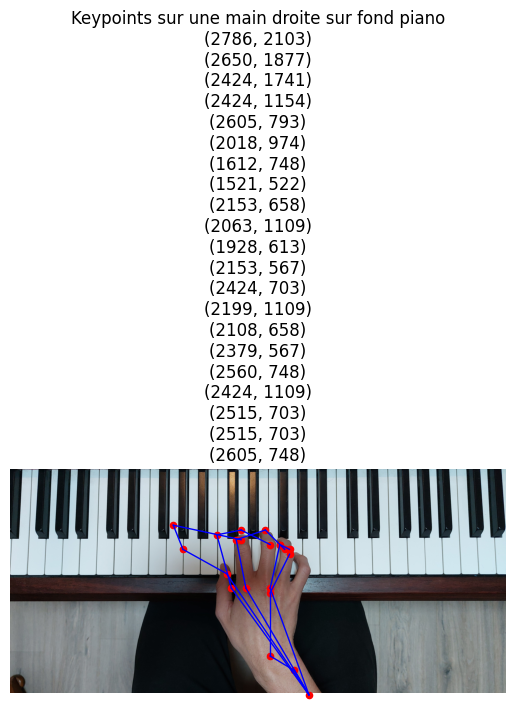

In [8]:
img_path = '/content/images/main_fond_piano.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()


On observe que la main n'est pas bien détectée, essayons en rognant l'image pour conserver uniquement la partie autour de la main que l'on veut détecter.

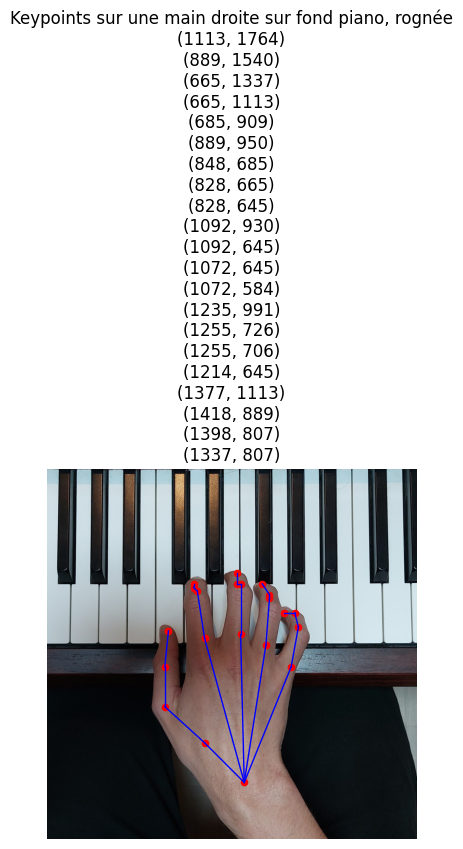

In [9]:
img_path = '/content/images/main_fond_piano_rognee.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano, rognée\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

On observe que le modèle fonctionne lorsque l'image contient principalement la main. Il faut donc redécouper chaque frame afin de ne garder que la main.

Redécoupe de l'image pour ne garder que la main

In [11]:
# On va utilise le framework MediaPipe de Google

# On crée un ensemble d'options pour le détecteur ainsi que le détecteur de mains
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options = base_options,num_hands = 2, min_hand_detection_confidence = 0.5)
detector = vision.HandLandmarker.create_from_options(options)

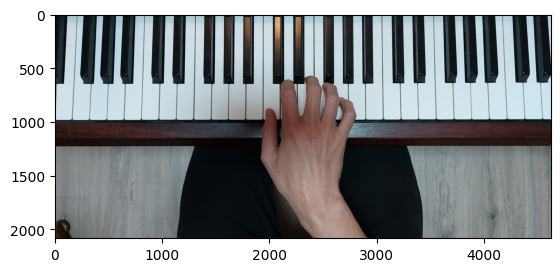

In [12]:
img_path = '/content/images/main_fond_piano.jpg'

# CV2 lit les images au format BGR au lieu de RGB
img_bgr = cv2.imread(img_path)
# On convertit en RGB au lieu de BGR
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)

In [13]:
# Création de l'image à analyser et détection des mains sur l'image
mp_image = Image(image_format = mp.ImageFormat.SRGB, data = img_rgb)
results = detector.detect(mp_image)

In [14]:
hauteur, largeur, _ = img_rgb.shape
hand_bboxes = []

for hand_landmarks in results.hand_landmarks:
    xs = [point.x for point in hand_landmarks]
    ys = [point.y for point in hand_landmarks]

    x1 = int(min(xs) * largeur)
    y1 = int(min(ys) * hauteur)
    x2 = int(max(xs) * largeur)
    y2 = int(max(ys) * hauteur)

    hand_bboxes.append((x1, y1, x2, y2))


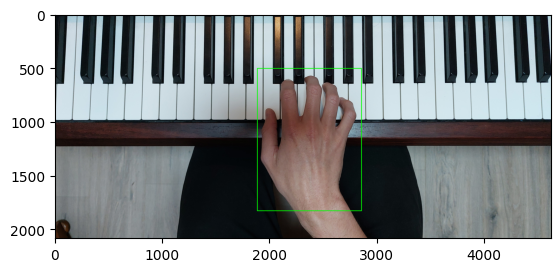

In [15]:
img = img_rgb.copy()
# Ajout d'un offset pour avoir l'ensemble de la main
OFFSET_X = 100
OFFSET_Y = 100

for (x1, y1, x2, y2) in hand_bboxes:
    x_min = max(0,x1 - OFFSET_X)
    x_max = min(x2 + OFFSET_X, largeur)
    y_min = max(0,y1 - OFFSET_Y)
    y_max = min(y2 + OFFSET_Y, hauteur)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)
    img_rognee = img[y_min:y_max, x_min:x_max]
    # Reconversion en BGR pour utiliser CV2
    img_rognee_rgb = cv2.cvtColor(img_rognee, cv2.COLOR_RGB2BGR)
    cv2.imwrite('/content/test/main_piano_rognée.png', img_rognee_rgb)

plt.imshow(img)

Extraction de chaque frame de la vidéo

On va maintenant transformer la vidéo en une suite de frames. On peut pour cela utiliser un pas pour l'extraction afin d'éviter des temps de calcul trop longs / utiliser trop de mémoire.

In [17]:
video_path = "/content/video/gamme_do_majeur.mp4"

# Pas pour l'extraction
step = 0
STEP_SIZE = 10

video = cv2.VideoCapture(video_path)
frame_id = 0
while True:
  ret, frame = video.read()
  if not ret:
     break
  if step % STEP_SIZE == 0:
    cv2.imwrite(f"full_frames/frame_{frame_id:03d}.png", frame)
    step = 0
  frame_id += 1
  step += 1;

video.release()

Redécoupage de chaque image en utilisant la logique vue précédemment

In [18]:
OFFSET_X = 200
OFFSET_Y = 100
# On enregistre les offsets pour revenir aux coordonnées originales
crop_offsets = {}

for img_path in sorted(glob.glob("/content/full_frames/*.png")):
  img_bgr = cv2.imread(img_path)
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  # Détection de la main
  mp_image = Image(image_format = mp.ImageFormat.SRGB, data = img_rgb)
  results = detector.detect(mp_image)
  hauteur, largeur, _ = img_rgb.shape
  hand_bboxes = []
  for hand_landmarks in results.hand_landmarks:
    xs = [point.x for point in hand_landmarks]
    ys = [point.y for point in hand_landmarks]
    x1 = int(min(xs) * largeur)
    y1 = int(min(ys) * hauteur)
    x2 = int(max(xs) * largeur)
    y2 = int(max(ys) * hauteur)
    hand_bboxes.append((x1, y1, x2, y2))
    img = img_rgb.copy()
  for (x1, y1, x2, y2) in hand_bboxes:
    # Sélection de la zone désirée
    x_min = max(0,x1 - OFFSET_X)
    x_max = min(x2 + OFFSET_X, largeur)
    y_min = max(0,y1 - OFFSET_Y)
    y_max = min(y2 + OFFSET_Y, hauteur)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)
    # Enregistrement
    img_rognee = img[y_min:y_max, x_min:x_max]
    img_rognee_rgb = cv2.cvtColor(img_rognee, cv2.COLOR_RGB2BGR)
    cv2.imwrite(f'/content/hand_frames/{os.path.basename(img_path)}', img_rognee_rgb)
    # On garde les offsets pour repasser des coordonnées relatives de découpe aux coordonnées absolues de l'image
    crop_offsets[os.path.basename(img_path)] = (x_min, y_min)

print(crop_offsets)


{'frame_000.png': (513, 266), 'frame_010.png': (514, 278), 'frame_020.png': (506, 277), 'frame_030.png': (508, 272), 'frame_040.png': (514, 277), 'frame_050.png': (520, 281), 'frame_060.png': (519, 285), 'frame_070.png': (536, 293), 'frame_080.png': (600, 278), 'frame_090.png': (605, 251), 'frame_100.png': (669, 241), 'frame_110.png': (725, 217), 'frame_120.png': (733, 224), 'frame_130.png': (715, 231), 'frame_140.png': (701, 241), 'frame_150.png': (702, 245), 'frame_160.png': (712, 249), 'frame_170.png': (716, 229), 'frame_180.png': (708, 233), 'frame_190.png': (705, 234), 'frame_200.png': (706, 225), 'frame_210.png': (705, 237), 'frame_220.png': (708, 244), 'frame_230.png': (708, 238), 'frame_240.png': (711, 252), 'frame_250.png': (702, 252), 'frame_260.png': (708, 254), 'frame_270.png': (717, 233), 'frame_280.png': (717, 231), 'frame_290.png': (706, 214), 'frame_300.png': (684, 216), 'frame_310.png': (638, 233), 'frame_320.png': (633, 230), 'frame_330.png': (603, 230), 'frame_340.pn

Prédiction sur chacune des frames

In [19]:
landmarks_list = []

for img_path in sorted(glob.glob("/content/hand_frames/*.png")):
  img_bgr = cv2.imread(img_path)
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  im_np = np.array(img_rgb)
  # Prédictions
  results = inference_topdown(model, img_path)
  pred = results[0] # Une seule main
  keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
  scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

  # Création d'une ligne de données pour le dataframe
  row = {"frame": os.path.basename(img_path)}
  offset_x, offset_y = crop_offsets.get(os.path.basename(img_path), (0, 0))
  for i, (pt, score) in enumerate(zip(keypoints, scores)):
    row[f"x_{i}"] = pt[0] + offset_x
    row[f"y_{i}"] = pt[1] + offset_y
    row[f"score_{i}"] = score
  landmarks_list.append(row)

df = pd.DataFrame(landmarks_list)

In [28]:
print(df.head(10))

           frame          x_0         y_0   score_0          x_1         y_1  \
0  frame_000.png   919.510742  893.254883  0.301871   808.036133  789.211914   
1  frame_010.png   915.168945  922.192383  0.311212   805.159180  797.514648   
2  frame_020.png   911.442383  935.690430  0.319889   800.260742  802.272461   
3  frame_030.png   912.374023  930.399414  0.317171   801.485352  804.725586   
4  frame_040.png   915.168945  917.358398  0.311213   805.159180  807.348633   
5  frame_050.png   918.498047  938.333984  0.326390   816.505859  807.201172   
6  frame_060.png   923.695312  937.523438  0.342048   814.710938  814.007812   
7  frame_070.png   942.423828  927.134766  0.331505   834.904297  819.615234   
8  frame_080.png  1031.327148  897.133789  0.364344   922.108398  801.567383   
9  frame_090.png  1122.444336  849.696289  0.362444  1014.192383  770.311523   

    score_1         x_2         y_2   score_2  ...  score_17         x_18  \
0  0.332750  711.424805  692.600586  0.340

In [21]:
df_pos = df.drop(columns = df.columns[df.columns.str.startswith('score')])
df_pos = df_pos.drop(columns = ['frame'])
nb_images = df_pos.values.shape[0]
# On récupère l'ensemble des keypoints par image
keypoints = [[] for _ in range(nb_images)]
for i in range(nb_images):
  values = df_pos.iloc[i,:].values
  for j in range(0, len(values),2):
    point = (values[j],values[j+1])
    keypoints[i].append(point)

# On crée une liste de listes qui contiennent chacune l'évolution d'un point au cours du temps
keypoints_evolution = [[] for _ in range(len(keypoints[0]))]
for i in range(len(keypoints)):
  keypoint = []
  for j in range(len(keypoints[i])):
    keypoints_evolution[j].append(keypoints[i][j])

print(keypoints_evolution)
nb_keypoints = len(keypoints_evolution)
print(f"Nombre de keypoints : {nb_keypoints}")

[[(np.float32(919.51074), np.float32(893.2549)), (np.float32(915.16895), np.float32(922.1924)), (np.float32(911.4424), np.float32(935.6904)), (np.float32(912.374), np.float32(930.3994)), (np.float32(915.16895), np.float32(917.3584)), (np.float32(918.49805), np.float32(938.334)), (np.float32(923.6953), np.float32(937.52344)), (np.float32(942.4238), np.float32(927.13477)), (np.float32(1031.3271), np.float32(897.1338)), (np.float32(1122.4443), np.float32(849.6963)), (np.float32(1164.0381), np.float32(881.58105)), (np.float32(1146.9277), np.float32(850.1113)), (np.float32(1151.8379), np.float32(852.4629)), (np.float32(1135.3994), np.float32(864.52246)), (np.float32(1131.0146), np.float32(886.4385)), (np.float32(1133.083), np.float32(899.15137)), (np.float32(1136.251), np.float32(904.86426)), (np.float32(1135.331), np.float32(925.13965)), (np.float32(1123.0576), np.float32(915.3096)), (np.float32(1117.3867), np.float32(912.33203)), (np.float32(1124.8379), np.float32(913.06055)), (np.float32

Calcul des trajectoires des Keypoints

1080 1920


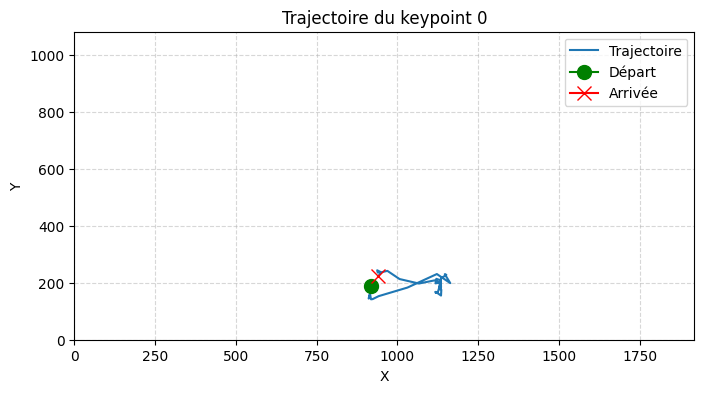

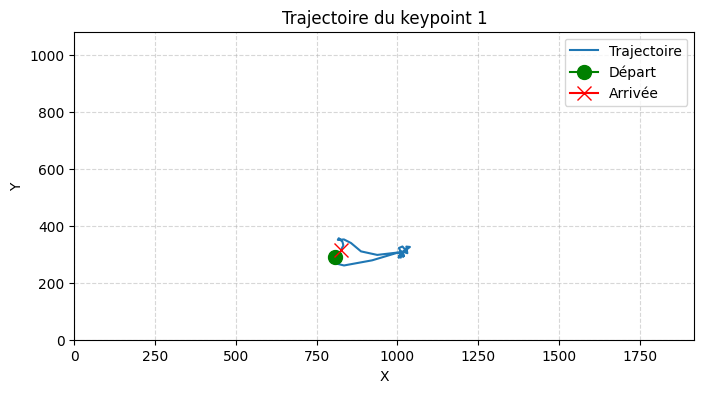

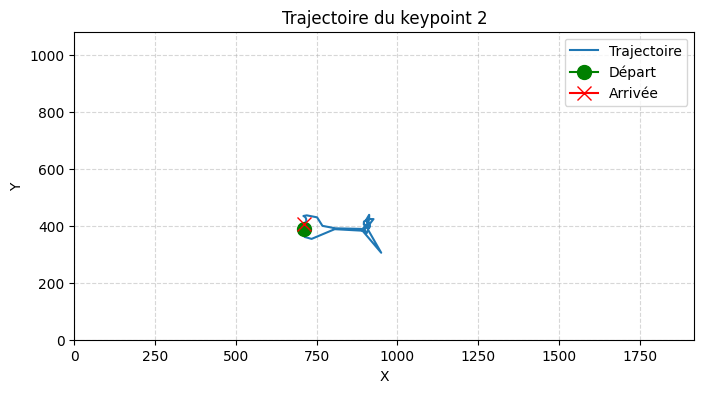

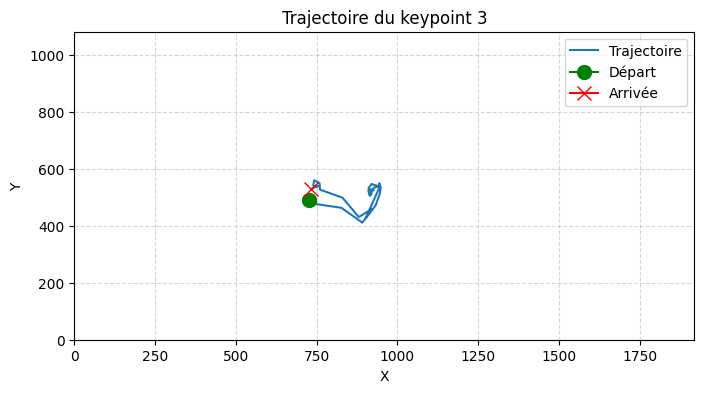

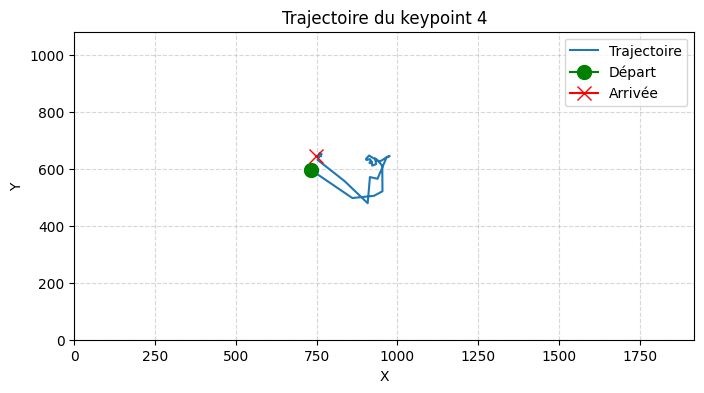

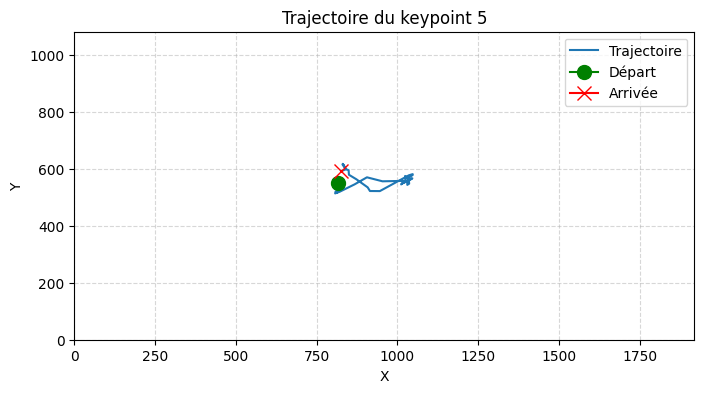

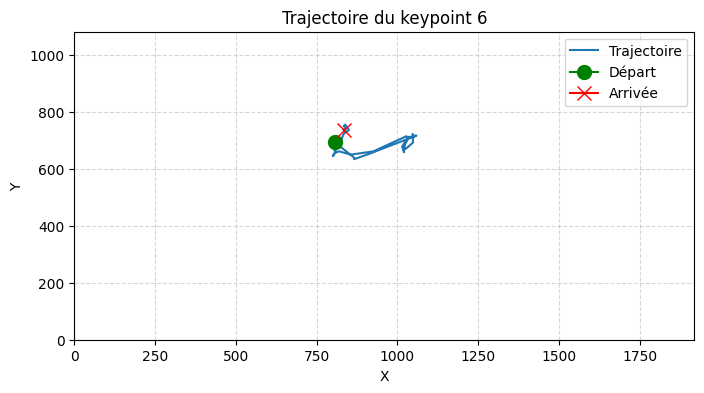

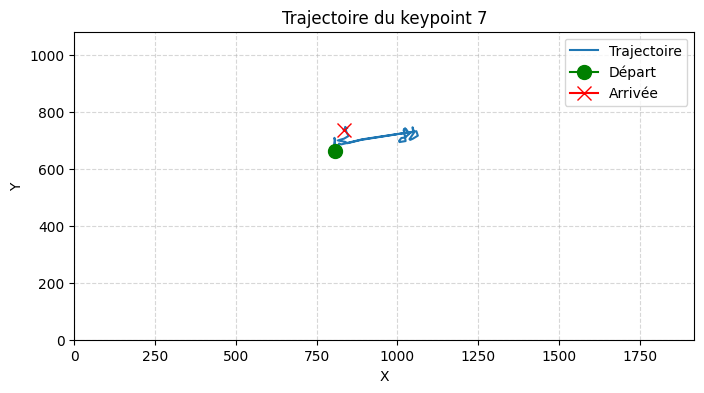

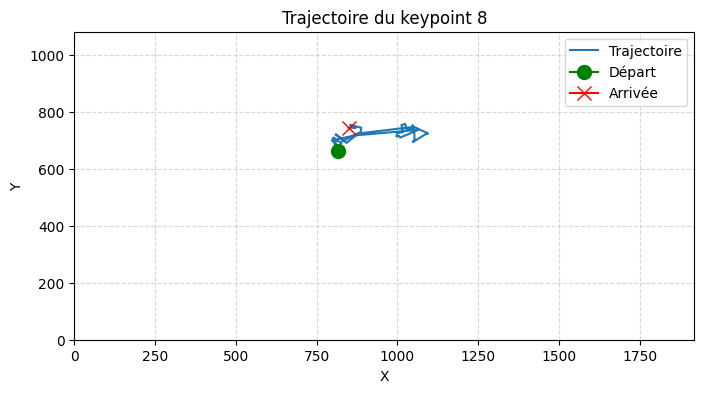

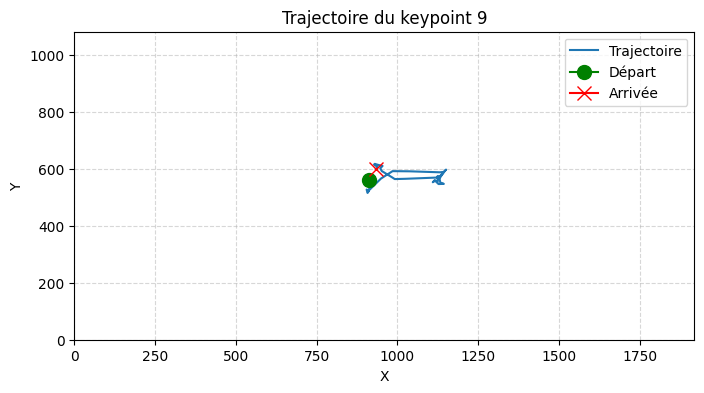

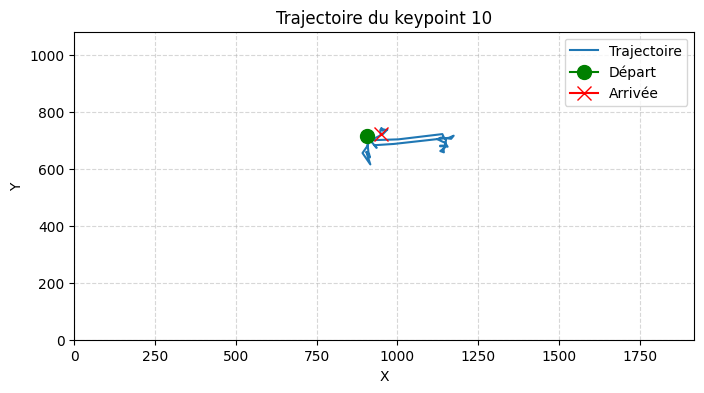

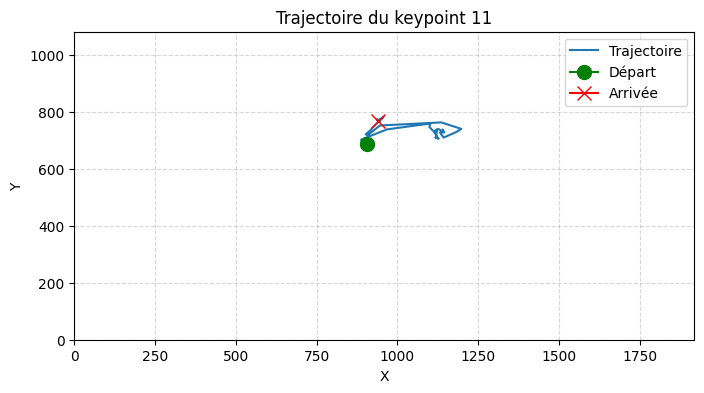

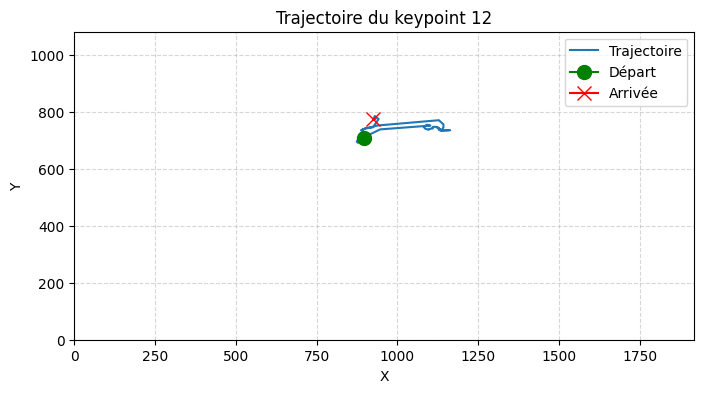

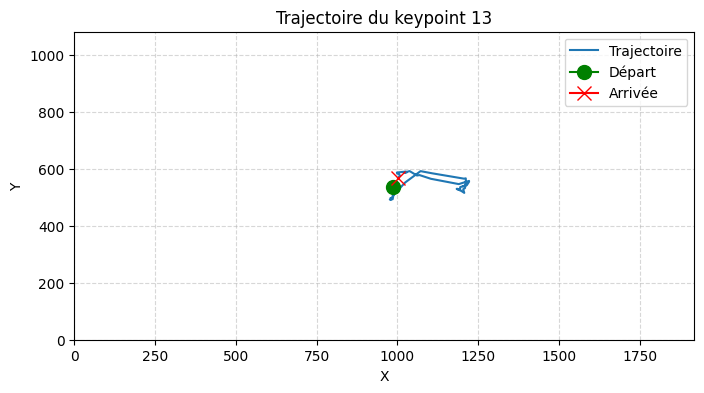

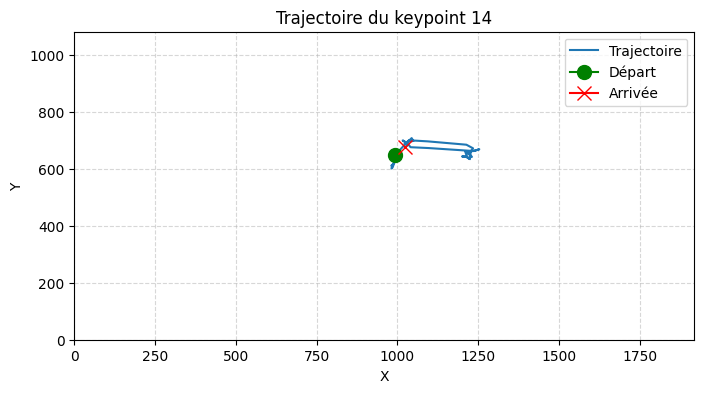

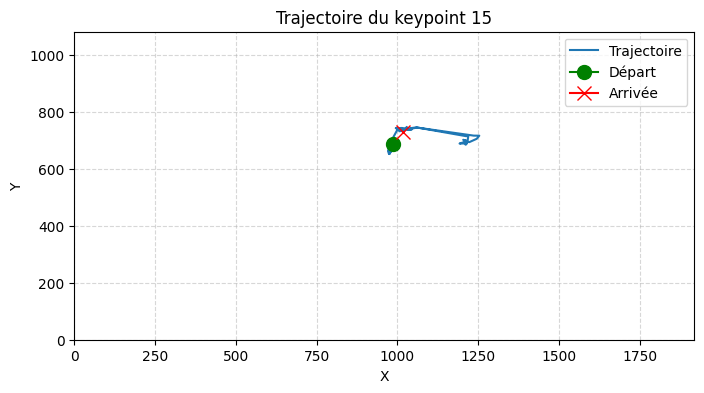

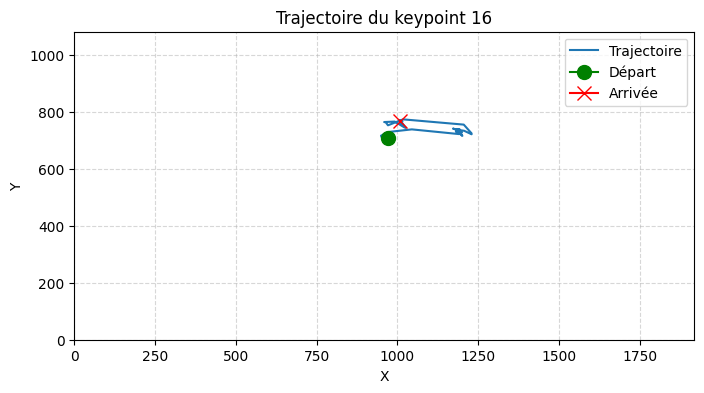

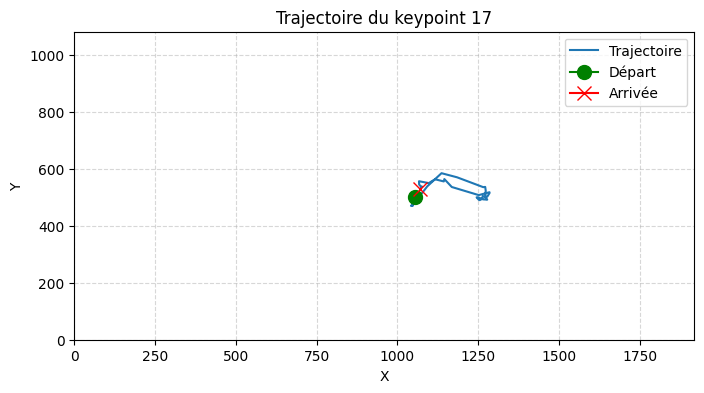

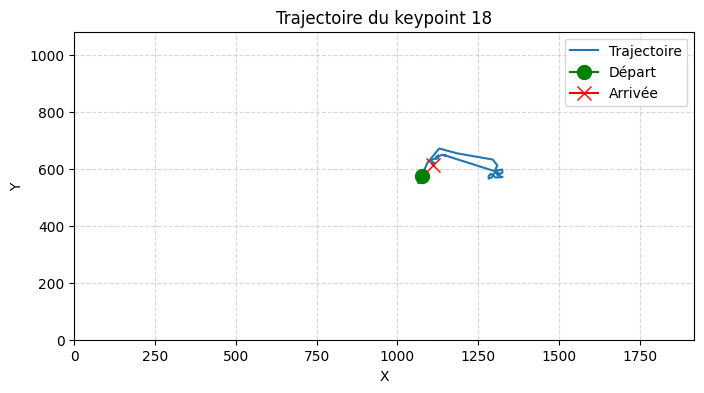

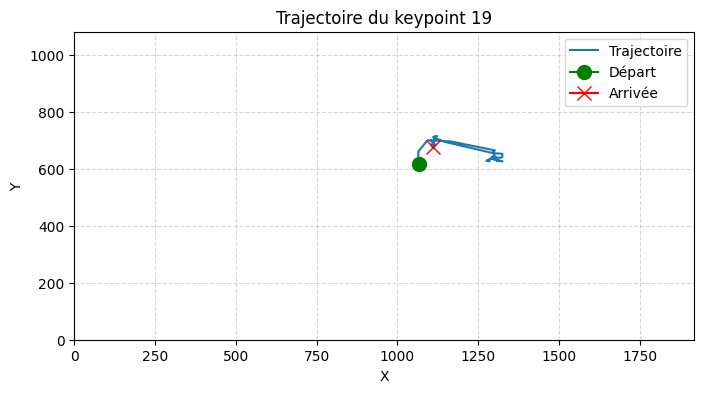

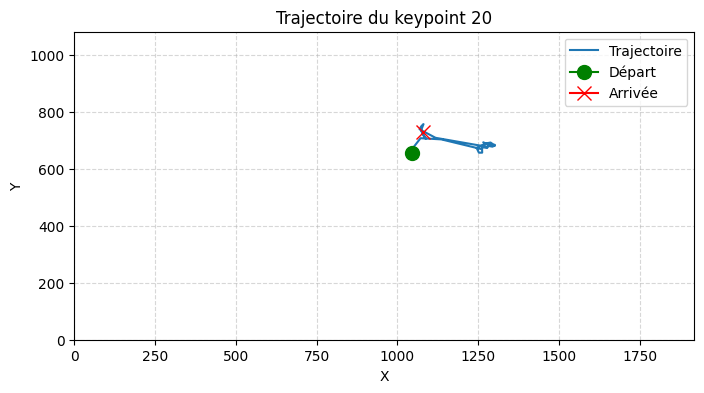

In [22]:
img = cv2.imread(glob.glob('/content/full_frames/*')[0])
hauteur, largeur = img.shape[:2]
print(hauteur,largeur)
for i in range(len(keypoints_evolution)):
  x, y = zip(*keypoints_evolution[i])
  plt.figure(figsize=(8, 4))
  y = [hauteur - y_i for y_i in y]

  plt.plot(x, y, label='Trajectoire')
  plt.plot(x[0], y[0], marker='o', markersize=10, color='green', label='Départ')
  plt.plot(x[-1], y[-1], marker='x', markersize=10, color='red', label='Arrivée')

  plt.title(f'Trajectoire du keypoint {i}')
  plt.xlabel('X')
  plt.ylabel('Y')

  plt.xlim(0, largeur)
  plt.ylim(0, hauteur)
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.legend()

  plt.show()

In [24]:
# Supprime les images en double (peut arriver si la vidéo se fige entre sur plusieurs frames)
def merge_duplicates(points):
    l = [points[0]]
    for p in points[1:]:
        if p != l[-1]:
            l.append(p)
    return l

Calcul des vitesses


On définit un intervalle de temps $\Delta t$ entre deux images successives en divisant le pas (ici step) par la fréquence de la vidéo (ici $59$ FPS). On calcule ensuite pour chaque point de la main, le déplacement pendant $\Delta t$ en utilisant la distance euclidienne $d((x_i,y_i),(x_{i+1},y_{i+1})) = \sqrt{(x_{i+1} - x_i)^2 + (y_{i+1} - y_i)^2}$. On obtient alors la vitesse moyenne $v = \frac{d((x_i,y_i),(x_{i+1},y_{i+1}))}{\Delta t}$

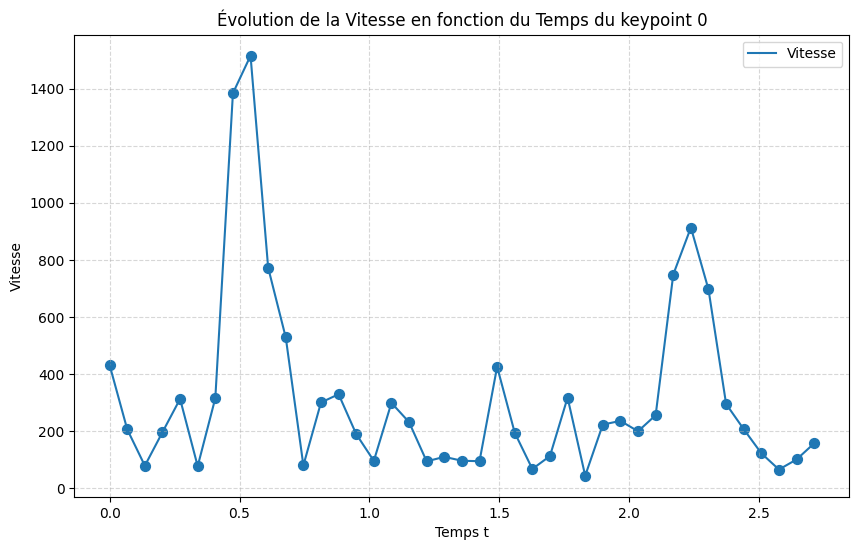

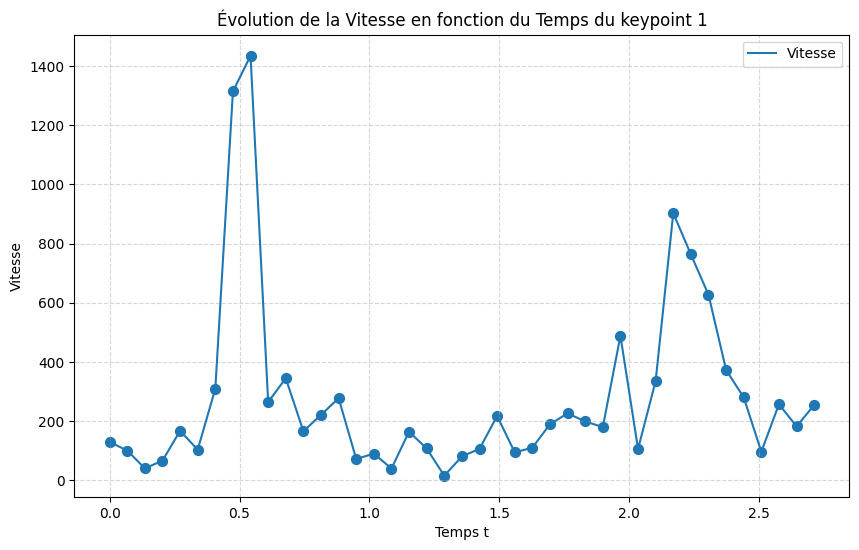

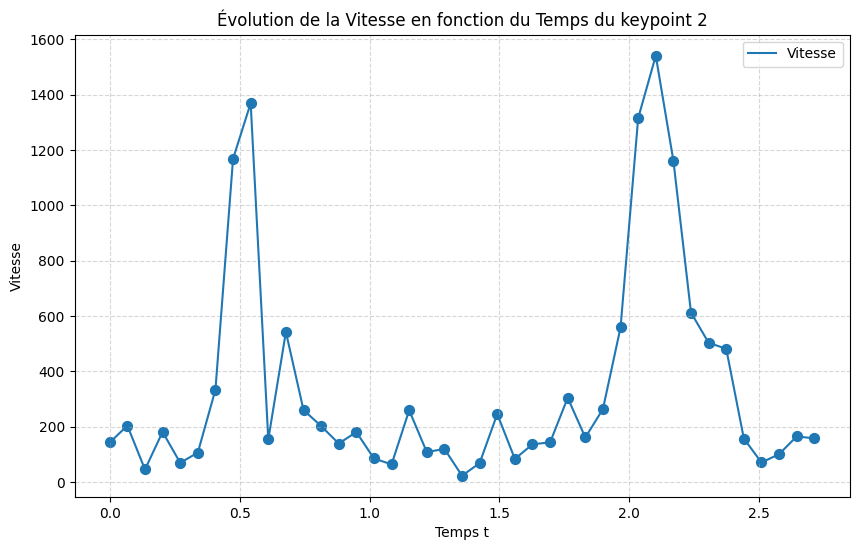

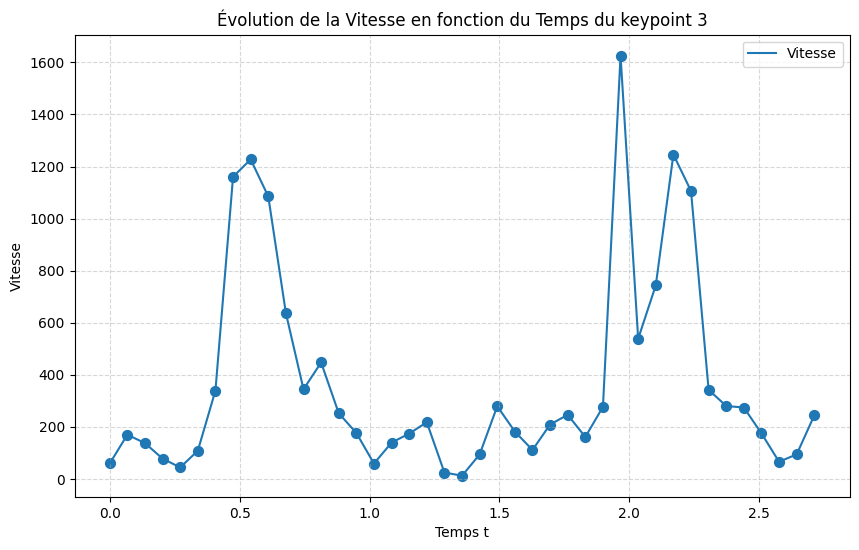

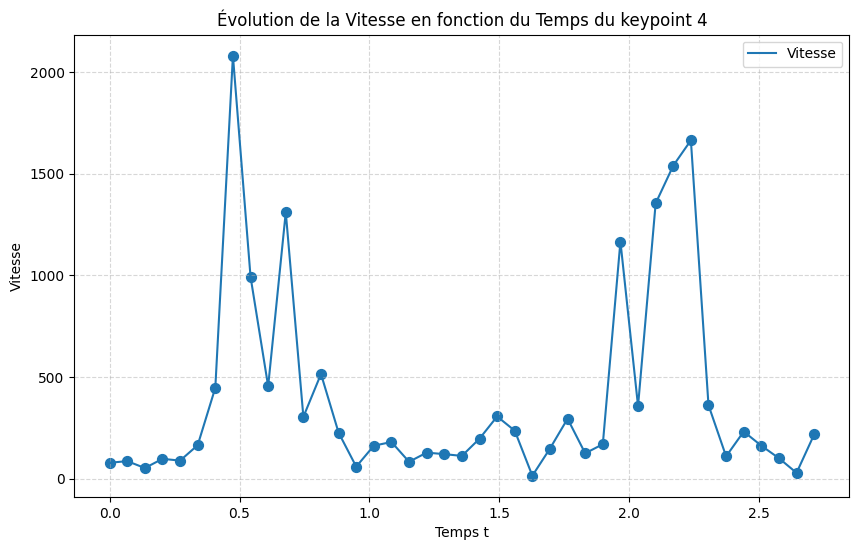

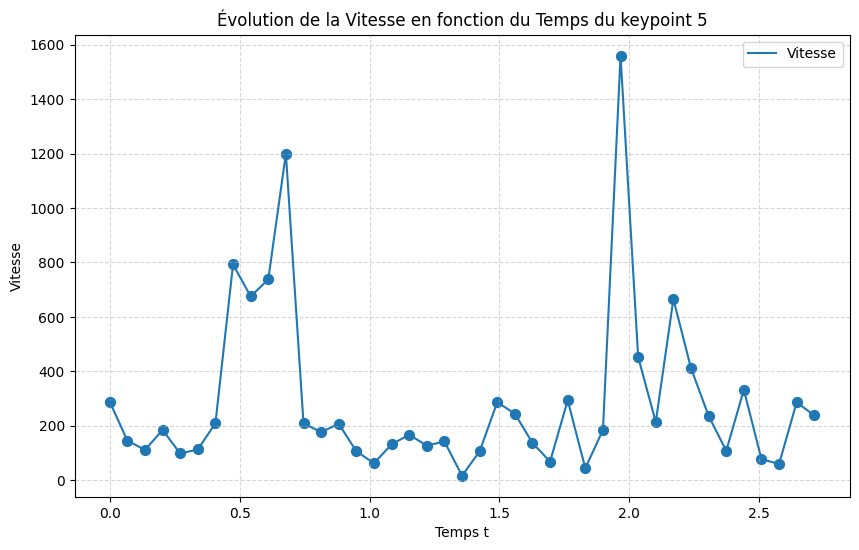

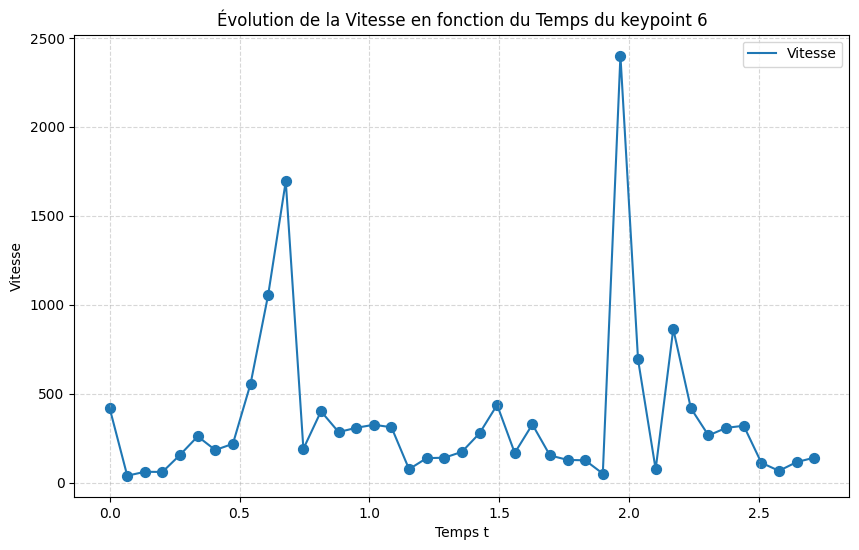

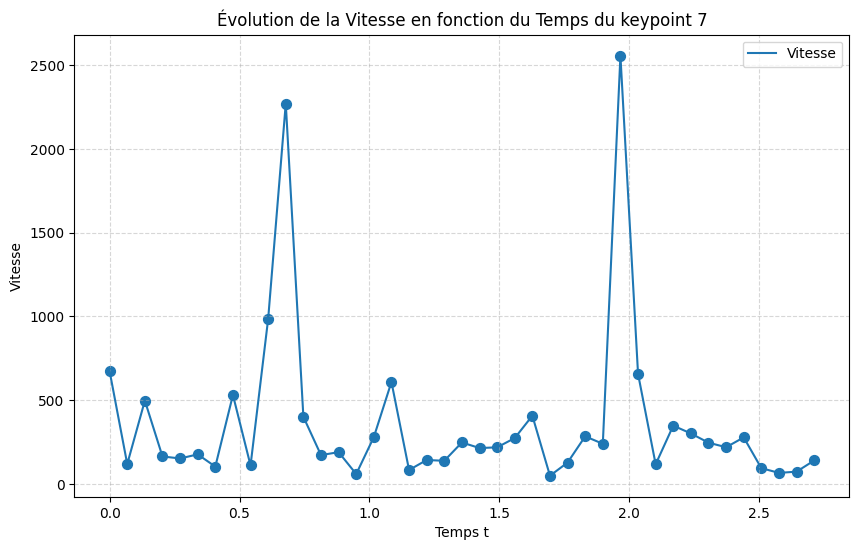

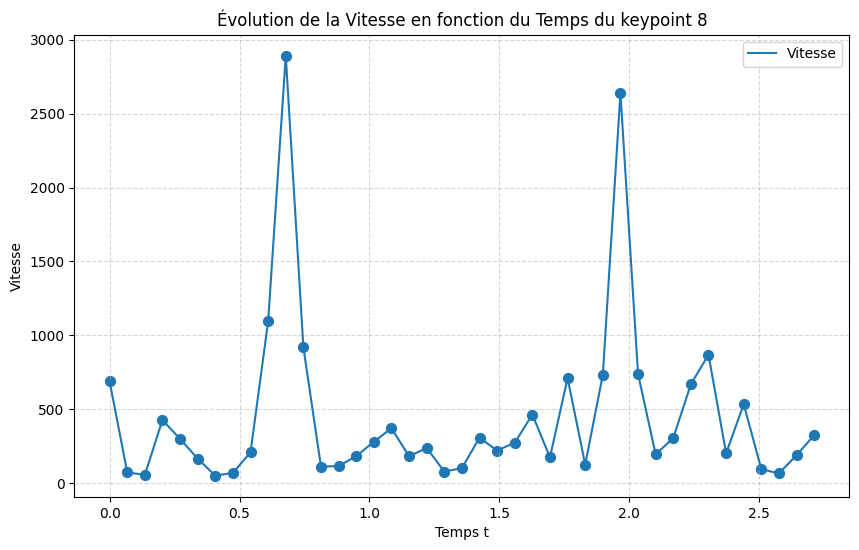

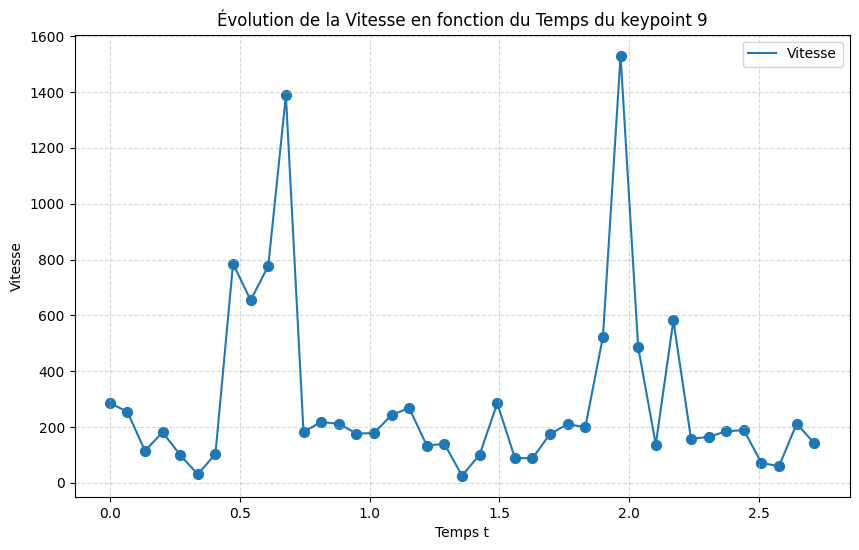

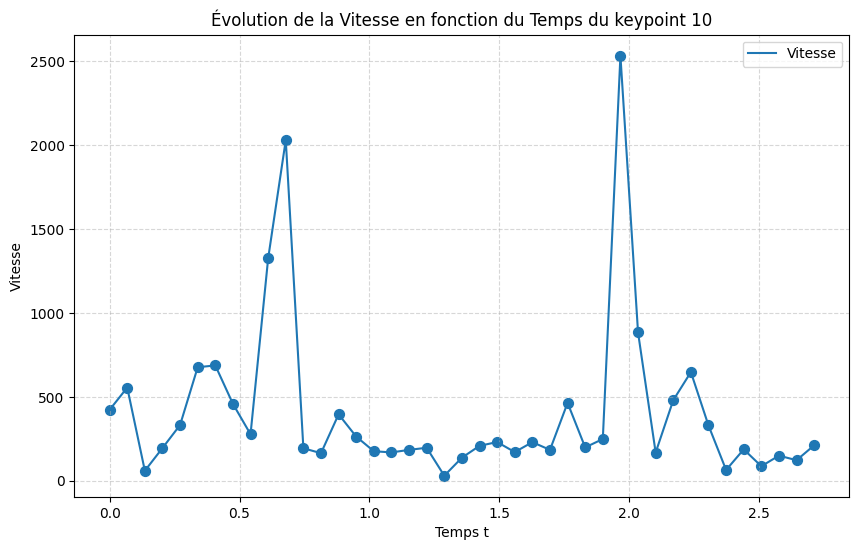

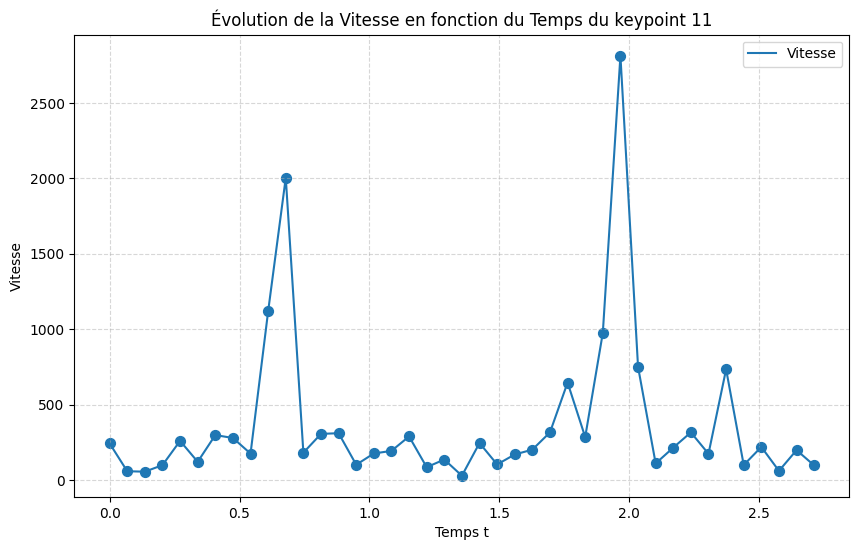

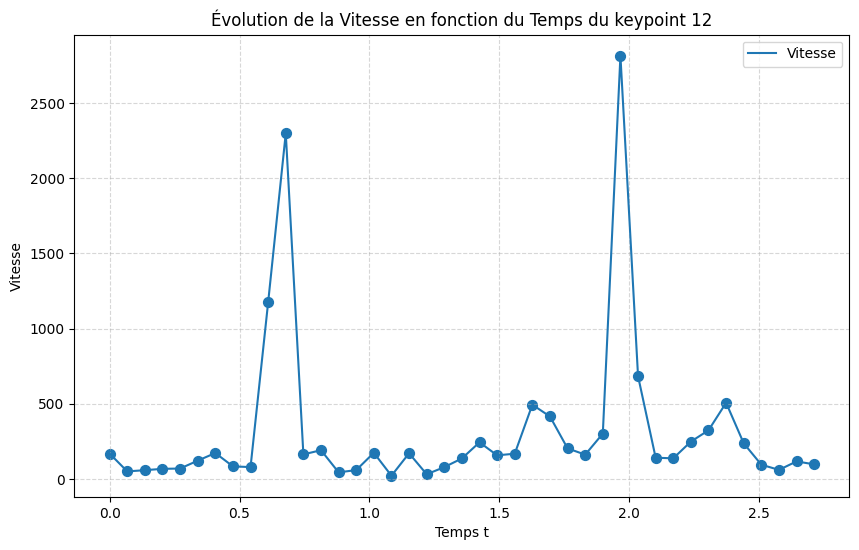

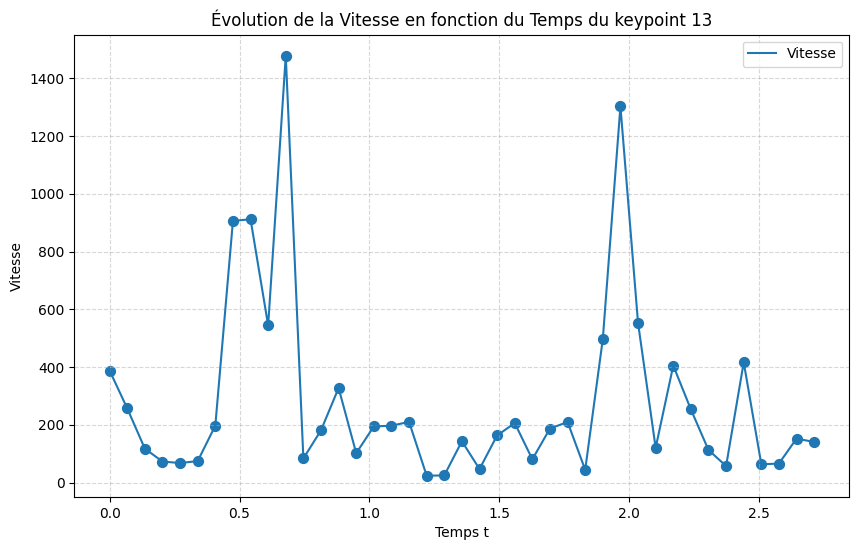

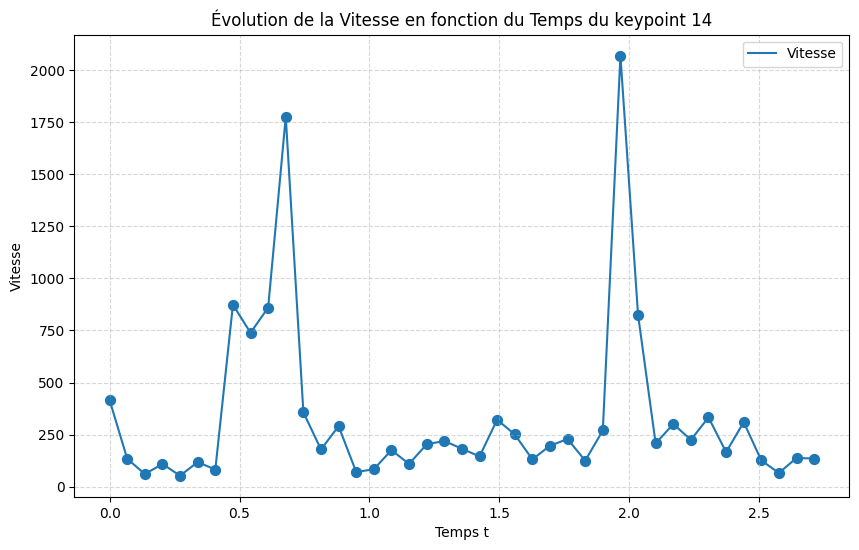

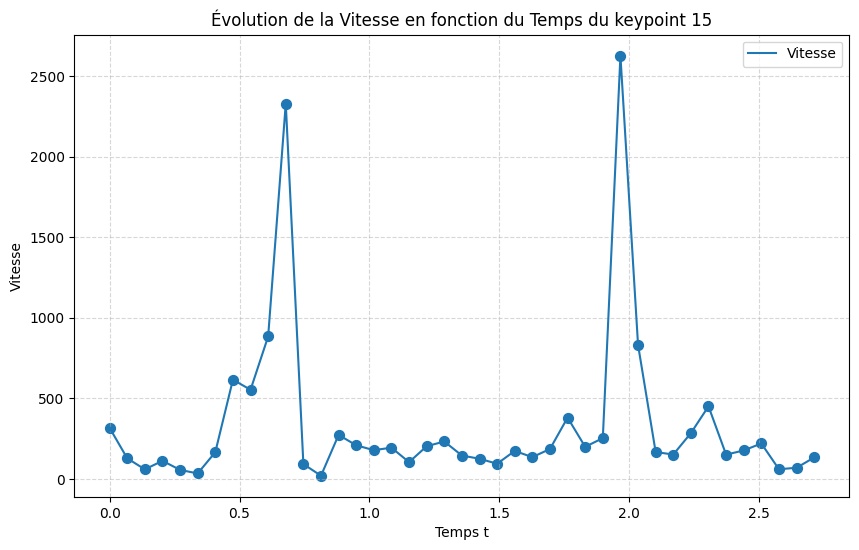

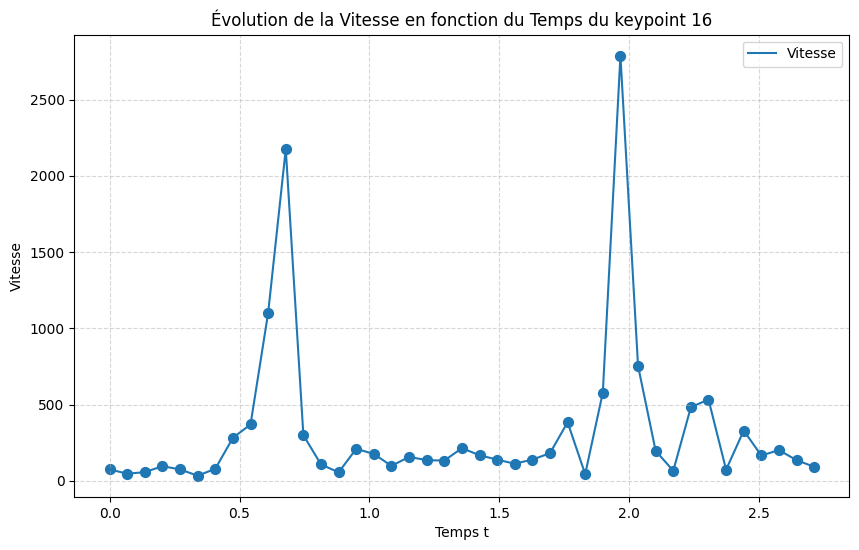

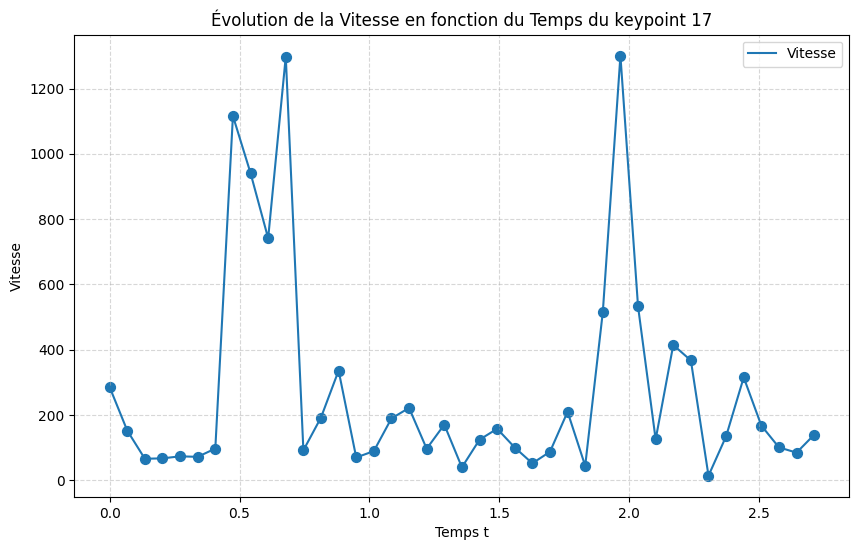

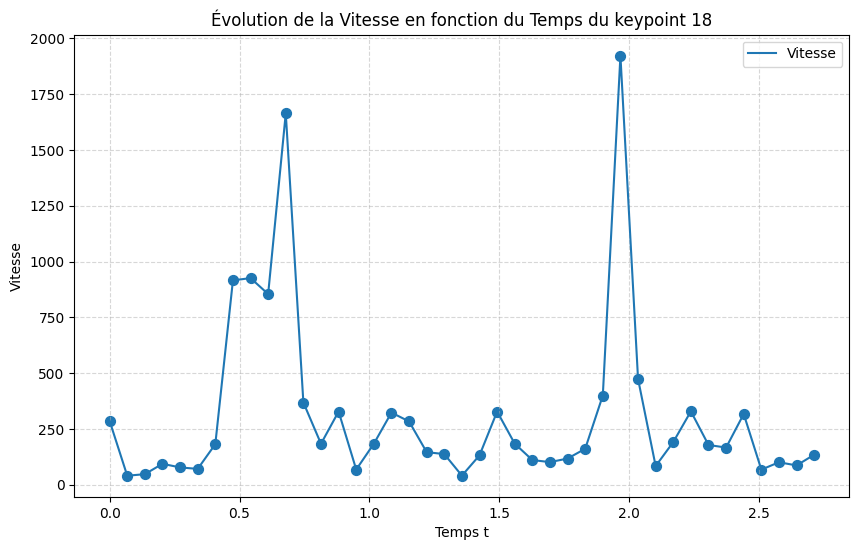

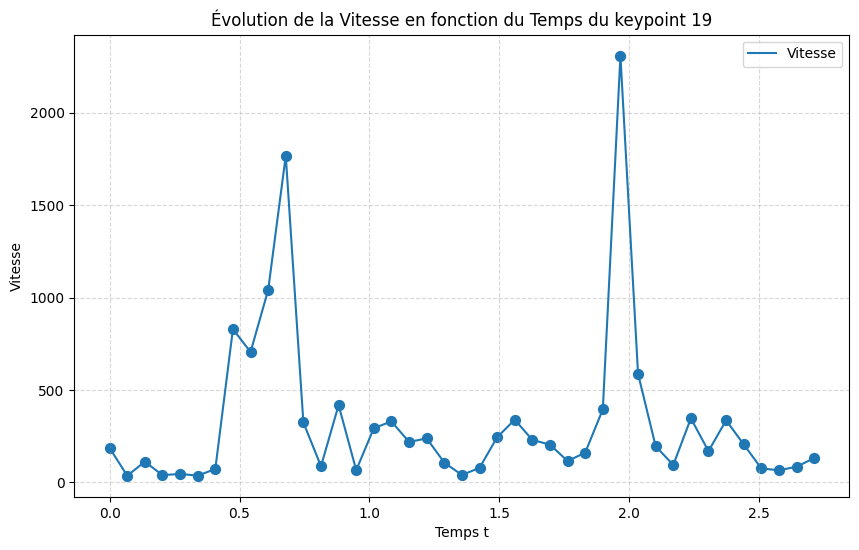

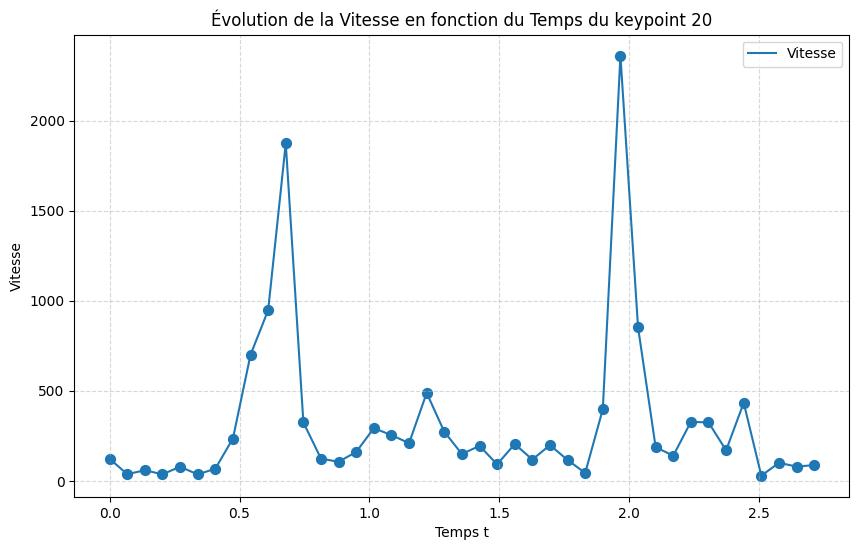

In [25]:
# la video est en 59 fps
delta = step/59
for i in range(nb_keypoints):
    points = keypoints_evolution[i]
    points = merge_duplicates(points)
    x, y = zip(*points)
    x = np.array(x)
    y = np.array(y)

    # np.diff : (x[i+1] - x[i])
    delta_x = np.diff(x)
    delta_y = np.diff(y)
    d = np.sqrt(delta_x**2 + delta_y**2)

    vitesse = d / delta
    t = np.arange(len(vitesse)) * delta

    plt.figure(figsize=(10, 6))
    plt.plot(t, vitesse, label='Vitesse')
    plt.scatter(t, vitesse, s=50)

    plt.title(f'Évolution de la Vitesse en fonction du Temps du keypoint {i}')
    plt.xlabel('Temps t')
    plt.ylabel('Vitesse')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()